# K-Nearest Neighbours (KNN) — Breast Cancer Classification

**Goal:** Classify breast tumors as Malignant or Benign by finding the K closest training samples to a query point and taking a majority vote.

**Dataset:** Same Wisconsin Breast Cancer dataset (569 samples, 30 features, binary target `M`/`B`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset

Load the same breast cancer CSV. We immediately separate the two classes into `M` (Malignant) and `B` (Benign) for visualisation.

In [2]:
data = pd.read_csv("../datasets/data.csv")

### Clean the Data

Drop the `id` column (no predictive value) and `Unnamed: 32` (empty column).  
Comments show the original label meaning: `M` = Malignant, `B` = Benign.

In [3]:
data.drop(["id", "Unnamed: 32"], axis=1,inplace=True)
data.head()
# malignant = M 
# benign = B

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
M = data[data.diagnosis == "M"] 
B = data[data.diagnosis == "B"] 

### Visualize: Malignant vs. Benign

A scatter plot of `radius_mean` vs. `texture_mean` reveals that the two classes are **partially separable** — malignant tumors (red) tend to have larger radius and texture values. KNN will exploit this spatial separation.

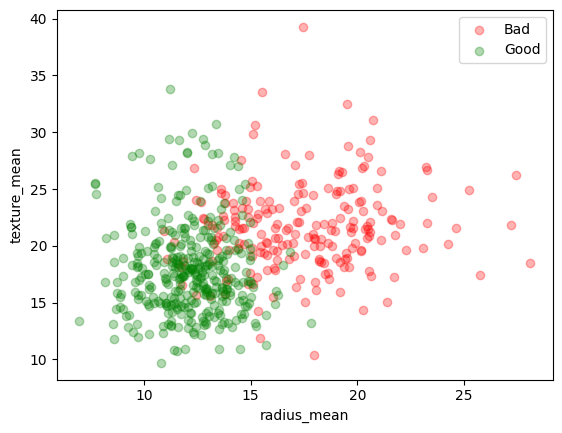

In [5]:
# scatter plot
plt.scatter(M.radius_mean, M.texture_mean,color="red", label="Bad",alpha=0.3)
plt.scatter(B.radius_mean, B.texture_mean,color="green", label="Good",alpha=0.3)
plt.xlabel("radius_mean")
plt.ylabel("texture_mean")
plt.legend()
plt.show()

### Encode Labels & Separate Features/Target

Map `'M'` → `1`, `'B'` → `0`. Drop `diagnosis` from the feature matrix `x_data`. `y` holds the numeric labels.

In [6]:
data.diagnosis = [1 if each == "M" else 0 for each in data.diagnosis]
x_data = data.drop(["diagnosis"], axis=1)
y = data.diagnosis.values

In [7]:
# Normalization
x = (x_data - np.min(x_data)) / np.max(x_data) - np.min(x_data)

### Train / Test Split

70% training, 30% testing. `random_state=1` ensures reproducible results.

In [8]:
# Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=1)

### KNN Model — K=3

`n_neighbors=3` means we look at the 3 closest training samples and take a majority vote.  
`knn.fit()` simply stores the training data — KNN is a **lazy learner** (no actual training computation happens here; all computation is deferred to prediction time).

In [9]:
# KNN model
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 3) # n_neighbors = k
knn.fit(x_train, y_train)
prediction = knn.predict(x_test)
prediction

array([0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0])

In [10]:
print("{} knn score {}".format(3,knn.score(x_test,y_test)))

3 knn score 0.9239766081871345


### Finding the Optimal K

We test K from 1 to 14 and plot accuracy on the test set. This helps us avoid:
- **K too small** (e.g. K=1) → overfitting — one noisy neighbor can change the result
- **K too large** → underfitting — we start including neighbors from the wrong class

The plot typically shows an **elbow** where accuracy peaks — in this dataset, **K=8** works best.

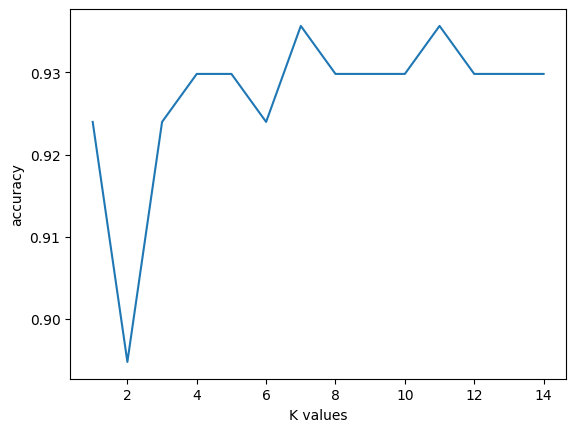

In [11]:
# find k value
score_list = []
for each in range(1,15):
    knn2 = KNeighborsClassifier(n_neighbors=each)
    knn2.fit(x_train,y_train)
    score_list.append(knn2.score(x_test,y_test))

plt.plot(range(1,15), score_list)
plt.xlabel("K values")
plt.ylabel("accuracy")
plt.show()

# Conclusion
* If K value is 8 then we get good results.